# Single-Layer Perceptron (SLP) — Attrition Prediction

## SLP Implementation (From Scratch)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.optim as optim


In [17]:
class SLP:
    """
    Single Layer Perceptron (no hidden layers).
    Architecture: Input(n_features) -> Linear -> Sigmoid -> Output(1)
    Loss: Binary Cross-Entropy
    """

    def __init__(self, input_dim):
        scale = np.sqrt(1.0 / input_dim)
        self.W = np.random.randn(input_dim, 1) * scale 
        self.b = np.zeros((1, 1)) 
        self.losses = []
        self.val_losses = []

    @staticmethod
    def sigmoid(Z):
        Z = np.clip(Z, -500, 500)
        return 1 / (1 + np.exp(-Z))

    def forward(self, X):
        # Z = X·W + b, A = sigmoid(Z)
        self.X = X
        self.Z = np.dot(X, self.W) + self.b 
        self.A = self.sigmoid(self.Z)
        return self.A

    def compute_loss(self, A, y):
        #Binary Cross-Entropy loss.
        eps = 1e-8
        A = np.clip(A, eps, 1 - eps)
        return -np.mean(y * np.log(A) + (1 - y) * np.log(1 - A))

    def backward(self, y):
        #Gradient of BCE + Sigmoid simplifies to (A - y).
        m = y.shape[0]
        dZ = self.A - y 
        dW = np.dot(self.X.T, dZ) / m 
        db = np.sum(dZ, axis=0, keepdims=True) / m 
        return dW, db

    def predict(self, X):
        #Forward pass and return probabilities.
        Z = np.dot(X, self.W) + self.b
        return self.sigmoid(Z)

    def train(self, X, y, epochs=10000, learning_rate=0.1, print_every=1000,
              X_val=None, y_val=None):
        for epoch in range(epochs):
            # Forward
            A = self.forward(X)

            # Loss
            loss = self.compute_loss(A, y)
            self.losses.append(loss)

            # Backward
            dW, db = self.backward(y)

            # Update weights
            self.W -= learning_rate * dW
            self.b -= learning_rate * db

            # Validation loss 
            if X_val is not None and y_val is not None:
                A_val = self.predict(X_val)
                val_loss = self.compute_loss(A_val, y_val)
                self.val_losses.append(val_loss)

            if print_every and epoch % print_every == 0:
                pred = (A >= 0.5).astype(int)
                acc = np.mean(pred == y)
                msg = f"Epoch {epoch:>5d} | Loss: {loss:.6f} | Train Acc: {acc:.4f}"
                if X_val is not None:
                    val_pred = (A_val >= 0.5).astype(int)
                    val_acc = np.mean(val_pred == y_val)
                    msg += f" | Val Loss: {val_loss:.6f} | Val Acc: {val_acc:.4f}"
                print(msg)

## Load & Prepare Data

In [18]:
# Load the RAW (non-SMOTE'd) dataset
df = pd.read_csv("../data/processed_data.csv")

# Convert Attrition values to binary (0 / 1)
attrition_vals = sorted(df["Attrition"].unique())
df["Attrition"] = df["Attrition"].map({attrition_vals[0]: 0, attrition_vals[1]: 1})

# Separate features and target
X = df.drop("Attrition", axis=1).values
y = df["Attrition"].values.reshape(-1, 1)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

smote = SMOTE(random_state=42)
X_train, y_train_smote = smote.fit_resample(X_train, y_train.ravel())
y_train = y_train_smote.reshape(-1, 1)

print(f"Features: {X.shape[1]}")
print(f"Train after SMOTE : {X_train.shape[0]} samples (balanced)")
print(f"Validation        : {X_val.shape[0]} samples (real)")
print(f"Test              : {X_test.shape[0]} samples (real)")
print(f"Train attrition rate (balanced): {y_train.mean():.2%}")
print(f"Val   attrition rate (real):     {y_val.mean():.2%}")
print(f"Test  attrition rate (real):     {y_test.mean():.2%}")


Features: 36
Train after SMOTE : 1724 samples (balanced)
Validation        : 220 samples (real)
Test              : 221 samples (real)
Train attrition rate (balanced): 50.00%
Val   attrition rate (real):     15.91%
Test  attrition rate (real):     16.29%


## Train the Model

In [19]:
np.random.seed(42)

model = SLP(input_dim=X_train.shape[1])

model.train(X_train, y_train, epochs=10000, learning_rate=0.05, print_every=1000,
            X_val=X_val, y_val=y_val)  


Epoch     0 | Loss: 0.778688 | Train Acc: 0.4785 | Val Loss: 0.751168 | Val Acc: 0.5227
Epoch  1000 | Loss: 0.470147 | Train Acc: 0.7889 | Val Loss: 0.475480 | Val Acc: 0.7545
Epoch  2000 | Loss: 0.467586 | Train Acc: 0.7889 | Val Loss: 0.465930 | Val Acc: 0.7591
Epoch  3000 | Loss: 0.467292 | Train Acc: 0.7865 | Val Loss: 0.464068 | Val Acc: 0.7545
Epoch  4000 | Loss: 0.467247 | Train Acc: 0.7860 | Val Loss: 0.463533 | Val Acc: 0.7545
Epoch  5000 | Loss: 0.467239 | Train Acc: 0.7865 | Val Loss: 0.463349 | Val Acc: 0.7591
Epoch  6000 | Loss: 0.467238 | Train Acc: 0.7865 | Val Loss: 0.463279 | Val Acc: 0.7591
Epoch  7000 | Loss: 0.467238 | Train Acc: 0.7865 | Val Loss: 0.463251 | Val Acc: 0.7591
Epoch  8000 | Loss: 0.467238 | Train Acc: 0.7865 | Val Loss: 0.463239 | Val Acc: 0.7591
Epoch  9000 | Loss: 0.467238 | Train Acc: 0.7865 | Val Loss: 0.463234 | Val Acc: 0.7591


## Performance Curve

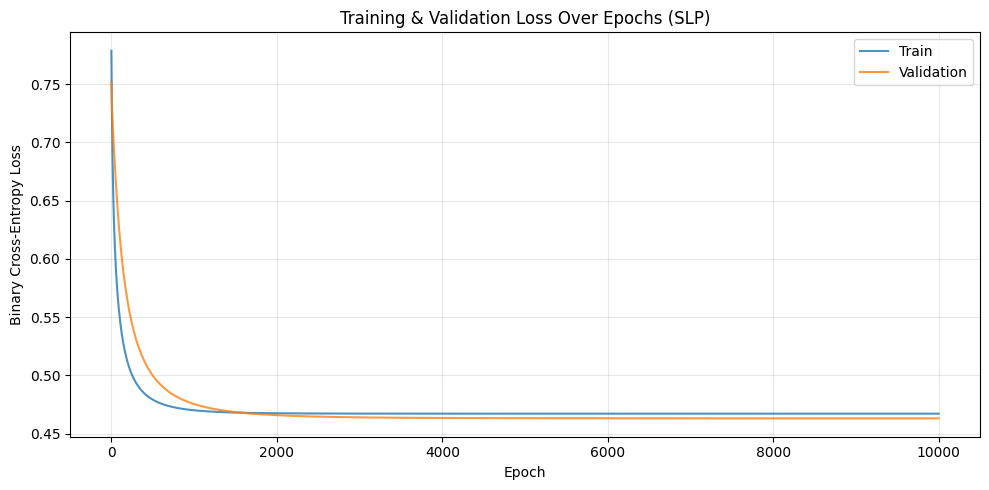

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(model.losses, label="Train", alpha=0.8)
if model.val_losses:
    plt.plot(model.val_losses, label="Validation", alpha=0.8)
plt.title("Training & Validation Loss Over Epochs (SLP)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation on Test Set

In [21]:
# Predict on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Accuracy, Precision, Recall, F1 Score, Specificity (True Negative Rate)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("=" * 45)
print("       SLP — Evaluation Results")
print("=" * 45)
print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Precision:   {precision:.4f}")
print(f"  Recall:      {recall:.4f}")
print(f"  Specificity: {specificity:.4f}")
print(f"  F1 Score:    {f1:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Attrition", "Attrition"]))

       SLP — Evaluation Results
  Accuracy:    0.7919
  Precision:   0.4107
  Recall:      0.6389
  Specificity: 0.8216
  F1 Score:    0.5000

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.92      0.82      0.87       185
   Attrition       0.41      0.64      0.50        36

    accuracy                           0.79       221
   macro avg       0.67      0.73      0.68       221
weighted avg       0.84      0.79      0.81       221



## Confusion Matrix

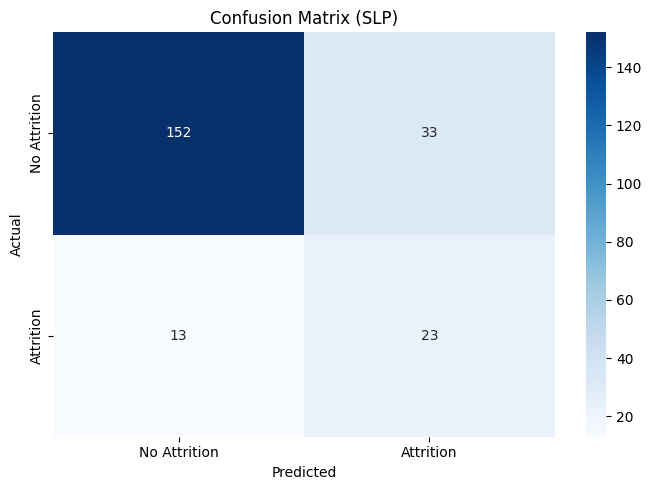

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (SLP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## ROC Curve & AUC

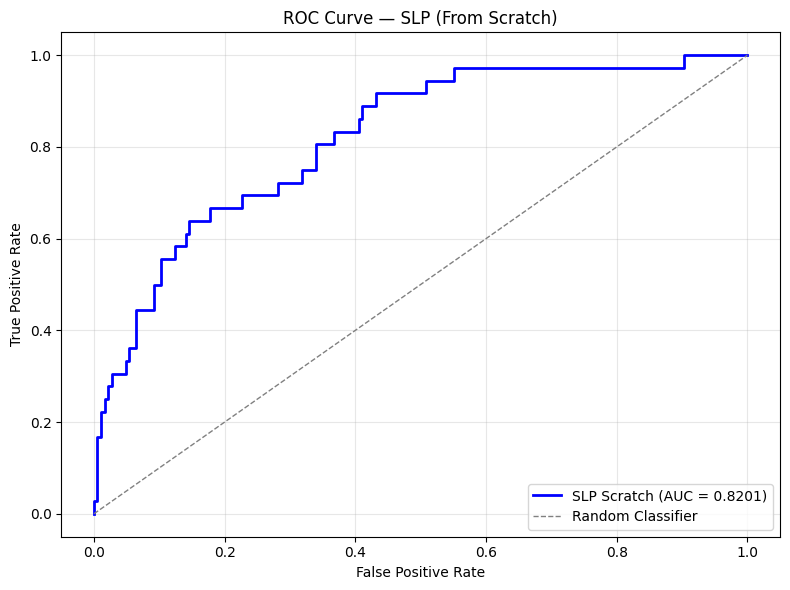

AUC Score: 0.8201


In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'SLP Scratch (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SLP (From Scratch)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

---
# PyTorch SLP — Comparison
Same architecture: **Input(36) → Linear → Sigmoid → Output(1)** — but using PyTorch with Adam optimizer.

In [24]:
# Convert data to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.FloatTensor(y_val)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test)

class PyTorchSLP(nn.Module):
    def __init__(self, input_dim):
        super(PyTorchSLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

pytorch_slp = PyTorchSLP(input_dim=X_train.shape[1])
print(pytorch_slp)
print(f"\nTotal parameters: {sum(p.numel() for p in pytorch_slp.parameters()):,}")


PyTorchSLP(
  (network): Sequential(
    (0): Linear(in_features=36, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

Total parameters: 37


## Train PyTorch SLP

In [25]:
torch.manual_seed(42)

criterion  = nn.BCELoss()
optimizer  = optim.Adam(pytorch_slp.parameters(), lr=0.001)

pytorch_train_losses = []
pytorch_val_losses   = []
epochs = 10000

for epoch in range(epochs):
    pytorch_slp.train()
    y_pred = pytorch_slp(X_train_t)
    loss   = criterion(y_pred, y_train_t)
    pytorch_train_losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ── Validation loss on val set (not test) ────────────────────────────────
    pytorch_slp.eval()
    with torch.no_grad():
        val_pred = pytorch_slp(X_val_t)        
        val_loss = criterion(val_pred, y_val_t)
        pytorch_val_losses.append(val_loss.item())

    if epoch % 1000 == 0:
        with torch.no_grad():
            pred    = (y_pred >= 0.5).float()
            acc     = (pred == y_train_t).float().mean()
            val_cls = (pytorch_slp(X_val_t) >= 0.5).float()
            val_acc = (val_cls == y_val_t).float().mean()
        print(f"Epoch {epoch:>5d} | Loss: {loss.item():.6f} | Train Acc: {acc.item():.4f} "
              f"| Val Loss: {val_loss.item():.6f} | Val Acc: {val_acc.item():.4f}")


Epoch     0 | Loss: 0.687955 | Train Acc: 0.5400 | Val Loss: 0.719792 | Val Acc: 0.4864
Epoch  1000 | Loss: 0.476611 | Train Acc: 0.7784 | Val Loss: 0.483753 | Val Acc: 0.7500
Epoch  2000 | Loss: 0.467874 | Train Acc: 0.7865 | Val Loss: 0.464090 | Val Acc: 0.7636
Epoch  3000 | Loss: 0.467256 | Train Acc: 0.7854 | Val Loss: 0.463104 | Val Acc: 0.7591
Epoch  4000 | Loss: 0.467238 | Train Acc: 0.7865 | Val Loss: 0.463215 | Val Acc: 0.7591
Epoch  5000 | Loss: 0.467238 | Train Acc: 0.7865 | Val Loss: 0.463230 | Val Acc: 0.7591
Epoch  6000 | Loss: 0.467238 | Train Acc: 0.7865 | Val Loss: 0.463236 | Val Acc: 0.7591
Epoch  7000 | Loss: 0.467238 | Train Acc: 0.7865 | Val Loss: 0.463231 | Val Acc: 0.7591
Epoch  8000 | Loss: 0.467238 | Train Acc: 0.7865 | Val Loss: 0.463230 | Val Acc: 0.7591
Epoch  9000 | Loss: 0.467238 | Train Acc: 0.7865 | Val Loss: 0.463230 | Val Acc: 0.7591


## PyTorch SLP — Loss Curve

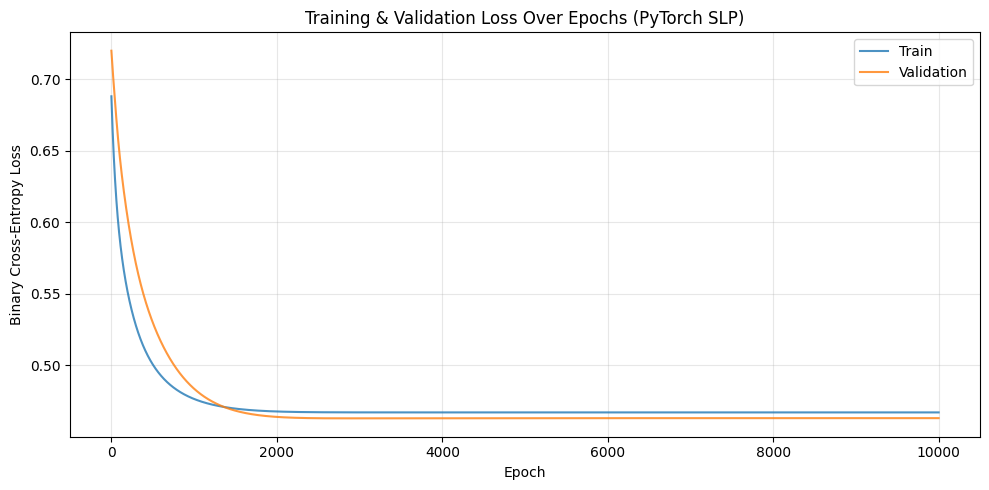

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(pytorch_train_losses, label="Train", alpha=0.8)
plt.plot(pytorch_val_losses, label="Validation", alpha=0.8)
plt.title("Training & Validation Loss Over Epochs (PyTorch SLP)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PyTorch SLP — Evaluation

In [27]:
pytorch_slp.eval()
with torch.no_grad():
    y_pred_prob_pt = pytorch_slp(X_test_t).numpy()
    y_pred_pt = (y_pred_prob_pt >= 0.5).astype(int)

accuracy_pt = accuracy_score(y_test, y_pred_pt)
precision_pt = precision_score(y_test, y_pred_pt)
recall_pt = recall_score(y_test, y_pred_pt)
f1_pt = f1_score(y_test, y_pred_pt)

cm_pt = confusion_matrix(y_test, y_pred_pt)
tn_pt, fp_pt, fn_pt, tp_pt = cm_pt.ravel()
specificity_pt = tn_pt / (tn_pt + fp_pt) if (tn_pt + fp_pt) > 0 else 0

print("=" * 45)
print("   PyTorch SLP — Evaluation Results")
print("=" * 45)
print(f"  Accuracy:    {accuracy_pt:.4f}")
print(f"  Precision:   {precision_pt:.4f}")
print(f"  Recall:      {recall_pt:.4f}")
print(f"  Specificity: {specificity_pt:.4f}")
print(f"  F1 Score:    {f1_pt:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pt, target_names=["No Attrition", "Attrition"]))

   PyTorch SLP — Evaluation Results
  Accuracy:    0.7919
  Precision:   0.4107
  Recall:      0.6389
  Specificity: 0.8216
  F1 Score:    0.5000

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.92      0.82      0.87       185
   Attrition       0.41      0.64      0.50        36

    accuracy                           0.79       221
   macro avg       0.67      0.73      0.68       221
weighted avg       0.84      0.79      0.81       221



## PyTorch SLP — Confusion Matrix

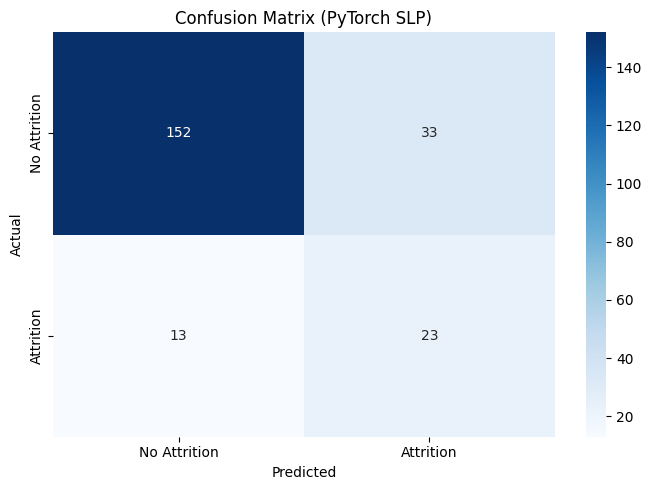

In [28]:
cm_pt = confusion_matrix(y_test, y_pred_pt)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_pt, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (PyTorch SLP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## ROC Curve & AUC (PyTorch SLP)

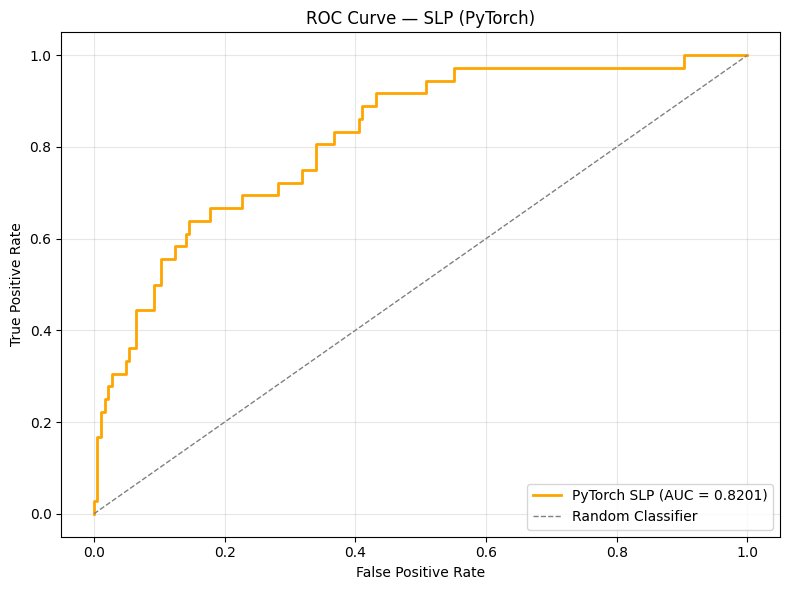

AUC Score (PyTorch): 0.8201


In [29]:
fpr_pt, tpr_pt, _ = roc_curve(y_test, y_pred_prob_pt)
roc_auc_pt = auc(fpr_pt, tpr_pt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_pt, tpr_pt, color='orange', lw=2, label=f'PyTorch SLP (AUC = {roc_auc_pt:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SLP (PyTorch)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score (PyTorch): {roc_auc_pt:.4f}")

## SLP Comparison: From Scratch vs PyTorch

     SLP Comparison: From Scratch vs PyTorch
     Metric  SLP (Scratch)  SLP (PyTorch)
   Accuracy       0.791855       0.791855
  Precision       0.410714       0.410714
     Recall       0.638889       0.638889
Specificity       0.821622       0.821622
   F1 Score       0.500000       0.500000
        AUC       0.820120       0.820120


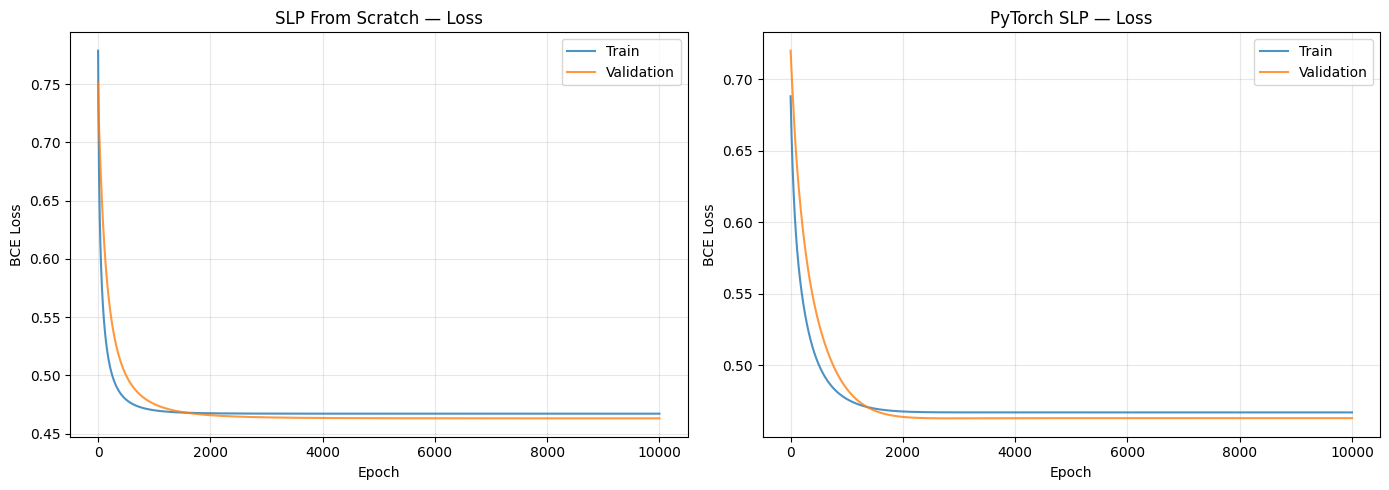

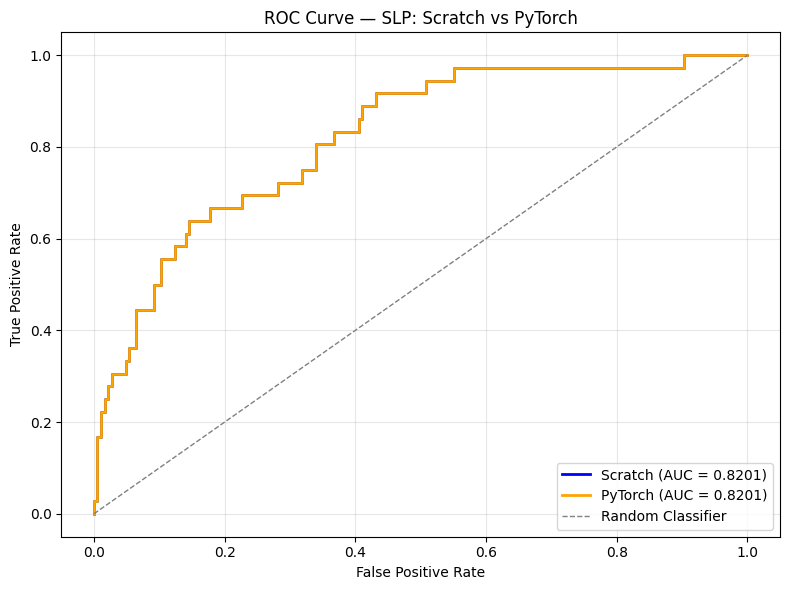

In [30]:
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score", "AUC"],
    "SLP (Scratch)": [accuracy, precision, recall, specificity, f1, roc_auc],
    "SLP (PyTorch)": [accuracy_pt, precision_pt, recall_pt, specificity_pt, f1_pt, roc_auc_pt]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 55)
print("     SLP Comparison: From Scratch vs PyTorch")
print("=" * 55)
print(comparison_df.to_string(index=False))
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model.losses, label="Train", alpha=0.8)
if model.val_losses:
    axes[0].plot(model.val_losses, label="Validation", alpha=0.8)
axes[0].set_title("SLP From Scratch — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(pytorch_train_losses, label="Train", alpha=0.8)
axes[1].plot(pytorch_val_losses, label="Validation", alpha=0.8)
axes[1].set_title("PyTorch SLP — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("BCE Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ROC Curve comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Scratch (AUC = {roc_auc:.4f})')
plt.plot(fpr_pt, tpr_pt, color='orange', lw=2, label=f'PyTorch (AUC = {roc_auc_pt:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SLP: Scratch vs PyTorch')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()